<a href="https://colab.research.google.com/github/aleks111sh/data-science-healthcare-AH/blob/main/Data_Science_Healthcare_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score

In [5]:
url = "https://raw.githubusercontent.com/aleks111sh/data-science-healthcare-AH/refs/heads/main/health_and_nutrition_combined_clean.csv"
df = pd.read_csv(url)
df = df.rename(columns={'Unnamed: 0':'ParticipantNumber'})
df = df.rename(columns={'RIAGENDR':'Gender'})
df = df.rename(columns={'RIDRETH3':'RaceEthnicity'})
df = df.rename(columns={'RIDAGEYR':'Age(yrs)'})
df = df.rename(columns={'BMXHT':'Stature(cm)'})
df = df.rename(columns={'BMXBMI':'BMI'})
df = df.rename(columns={'BMXWT':'Mass(kg)'})
df = df.rename(columns={'RIDEXPRG':'PregnancyStatus'})
df = df.rename(columns={'WTMEC4YR':'ExamWeight'})
df = df.drop(columns=['ExamWeight'])
df = df.drop(columns=['SEQN'])
df['Gender'] = df['Gender'].replace(1,'M')
df['Gender'] = df['Gender'].replace(2,'F')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(1, 'Mexican American')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(2, 'Other Hispanic')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(3, 'White')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(4, 'African American')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(5, 'Not Used')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(6, 'Asian')
df['RaceEthnicity'] = df['RaceEthnicity'].replace(7, 'Other Race')
df['PregnancyStatus'] = df['PregnancyStatus'].fillna(value=2)
df['PregnancyStatus'] = df['PregnancyStatus'].replace(2.0, 'Not Pregnant')
df['PregnancyStatus'] = df['PregnancyStatus'].replace(3.0, 'Unsure')
df['Stature(cm)'] = df['Stature(cm)']/10
df = df[df['Stature(cm)']<=188.562]
df = df[df['Stature(cm)']>=143.862]
df = df[df['BMI']<=42.734]
df = df[df['BMI']>=16.634]
df = df[df['Mass(kg)']<=123.24]
df = df[df['Mass(kg)']>=41.34]
df.head()

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(cm),BMI,Mass(kg),PregnancyStatus
0,0,M,White,62,184.5,27.8,94.8,Not Pregnant
1,1,M,White,53,171.4,30.8,90.4,Not Pregnant
2,2,M,White,78,170.1,28.8,83.4,Not Pregnant
3,3,M,African American,22,165.4,28.0,76.6,Not Pregnant
4,4,M,African American,56,179.4,33.6,108.3,Not Pregnant


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9504 entries, 0 to 10613
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ParticipantNumber  9504 non-null   int64  
 1   Gender             9504 non-null   object 
 2   RaceEthnicity      9504 non-null   object 
 3   Age(yrs)           9504 non-null   int64  
 4   Stature(cm)        9504 non-null   float64
 5   BMI                9504 non-null   float64
 6   Mass(kg)           9504 non-null   float64
 7   PregnancyStatus    9504 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 668.2+ KB


In [7]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9504 entries, 0 to 10613
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ParticipantNumber  9504 non-null   int64  
 1   Gender             9504 non-null   object 
 2   RaceEthnicity      9504 non-null   object 
 3   Age(yrs)           9504 non-null   int64  
 4   Stature(cm)        9504 non-null   float64
 5   BMI                9504 non-null   float64
 6   Mass(kg)           9504 non-null   float64
 7   PregnancyStatus    9504 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 668.2+ KB


In [8]:
df.head()

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(cm),BMI,Mass(kg),PregnancyStatus
0,0,M,White,62,184.5,27.8,94.8,Not Pregnant
1,1,M,White,53,171.4,30.8,90.4,Not Pregnant
2,2,M,White,78,170.1,28.8,83.4,Not Pregnant
3,3,M,African American,22,165.4,28.0,76.6,Not Pregnant
4,4,M,African American,56,179.4,33.6,108.3,Not Pregnant


In [9]:
df.describe()

,ParticipantNumber,Age(yrs),Stature(cm),BMI,Mass(kg)
count,9504.000000,9504.000000,9504.000000,9504.000000,9504.000000
mean,5303.777778,50.826494,165.856050,28.432818,78.377799
std,3063.162063,17.739153,9.532657,5.389761,16.854161
min,0.000000,20.000000,143.900000,16.700000,41.500000
25%,2635.750000,35.000000,158.600000,24.400000,65.800000
50%,5319.500000,52.000000,165.700000,28.000000,77.100000
75%,7944.250000,65.000000,173.000000,32.100000,89.800000
max,10613.000000,80.000000,188.500000,42.700000,123.200000


In [10]:
df = df.sort_values(by='ParticipantNumber',ascending=True)
df.head()

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(cm),BMI,Mass(kg),PregnancyStatus
0,0,M,White,62,184.5,27.8,94.8,Not Pregnant
1,1,M,White,53,171.4,30.8,90.4,Not Pregnant
2,2,M,White,78,170.1,28.8,83.4,Not Pregnant
3,3,M,African American,22,165.4,28.0,76.6,Not Pregnant
4,4,M,African American,56,179.4,33.6,108.3,Not Pregnant


In [11]:
mexican = df['RaceEthnicity'] == 'Mexican American'
other_hispanic = df['RaceEthnicity'] == 'Other Hispanic'
white = df['RaceEthnicity'] == 'White'
african_american = df['RaceEthnicity'] == 'African American'
n_a = df['RaceEthnicity'] == 'Not Used'
asian = df['RaceEthnicity'] == 'Asian'
other_race = df['RaceEthnicity'] == 'Other Race'
df['RaceEthnicity'].value_counts()

,count
RaceEthnicity,
White,3170
Mexican American,2583
African American,2028
Asian,1334
Other Race,389


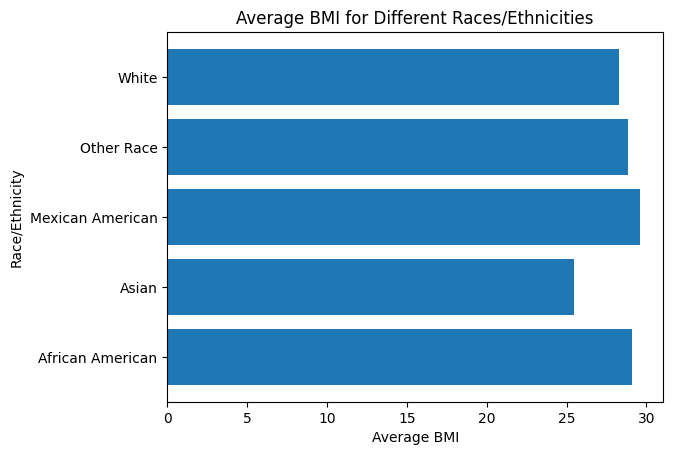

In [12]:
groups1 = df.groupby('RaceEthnicity')['BMI']
bar_x1 = groups1.mean().index
bar_y1 = groups1.mean()
plt.barh(bar_x1,bar_y1)
plt.title('Average BMI for Different Races/Ethnicities')
plt.ylabel('Race/Ethnicity')
plt.xlabel('Average BMI')
plt.show()

In [13]:
df_aa = df[df['RaceEthnicity']=='African American']
df_m = df[df['RaceEthnicity']=='Mexican American']
df_a = df[df['RaceEthnicity']=='Asian']
df_or = df[df['RaceEthnicity']=='Other Race']
df_w = df[df['RaceEthnicity']=='White']
df_male = df[df['Gender']=='M']
df_female = df[df['Gender']=='F']
df_notp = df[df['PregnancyStatus']=='Not Pregnant']

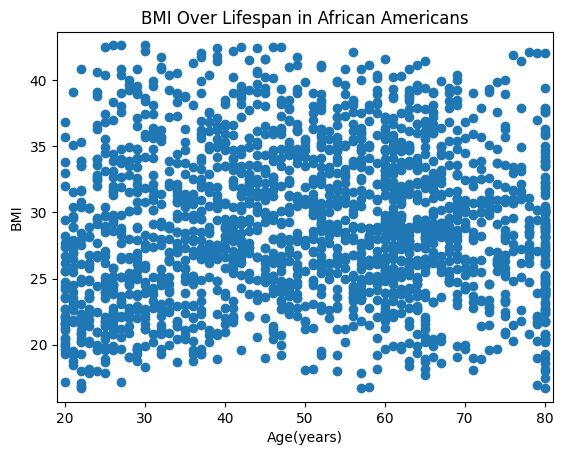

In [14]:
scatter_x1 = df_aa['Age(yrs)']
scatter_y1 = df_aa['BMI']
plt.scatter(scatter_x1,scatter_y1)
plt.title('BMI Over Lifespan in African Americans')
plt.xlim(df_aa['Age(yrs)'].min()-1,df_aa['Age(yrs)'].max()+1)
plt.ylim(df_aa['BMI'].min()-1,df_aa['BMI'].max()+1)
plt.xlabel('Age(years)')
plt.ylabel('BMI')
plt.show()

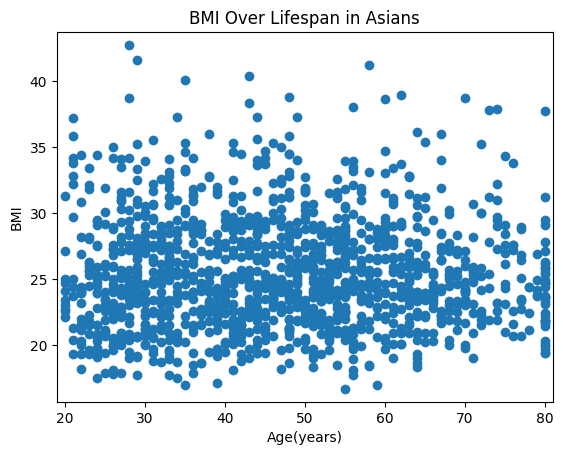

In [15]:
scatter_x5 = df_a['Age(yrs)']
scatter_y5 = df_a['BMI']
plt.scatter(scatter_x5,scatter_y5)
plt.title('BMI Over Lifespan in Asians')
plt.xlim(df_a['Age(yrs)'].min()-1,df_a['Age(yrs)'].max()+1)
plt.ylim(df_a['BMI'].min()-1,df_a['BMI'].max()+1)
plt.xlabel('Age(years)')
plt.ylabel('BMI')
plt.show()

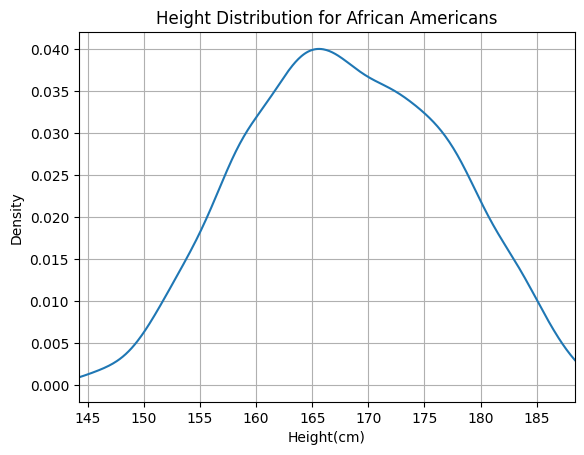

In [16]:
df_aa['Stature(cm)'].plot(kind='density')
plt.title('Height Distribution for African Americans')
plt.xlim(df_aa['Stature(cm)'].min(),df_aa['Stature(cm)'].max())
plt.xlabel('Height(cm)')
plt.ylabel('Density')
plt.grid()

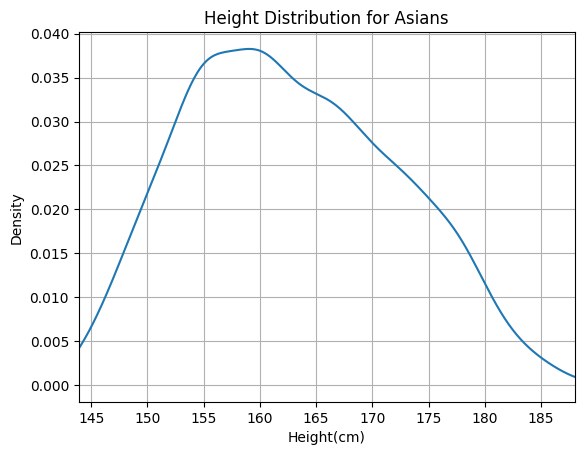

In [17]:
df_a['Stature(cm)'].plot(kind='density')
plt.title('Height Distribution for Asians')
plt.xlim(df_a['Stature(cm)'].min(),df_a['Stature(cm)'].max())
plt.xlabel('Height(cm)')
plt.ylabel('Density')
plt.grid()

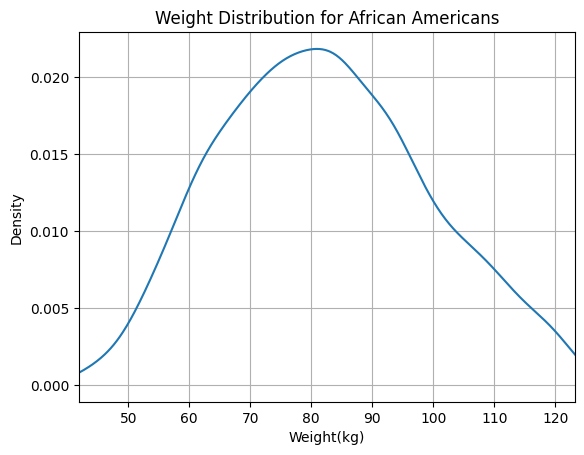

In [18]:
df_aa['Mass(kg)'].plot(kind='density')
plt.title('Weight Distribution for African Americans')
plt.xlim(df_aa['Mass(kg)'].min(),df_aa['Mass(kg)'].max())
plt.xlabel('Weight(kg)')
plt.ylabel('Density')
plt.grid()

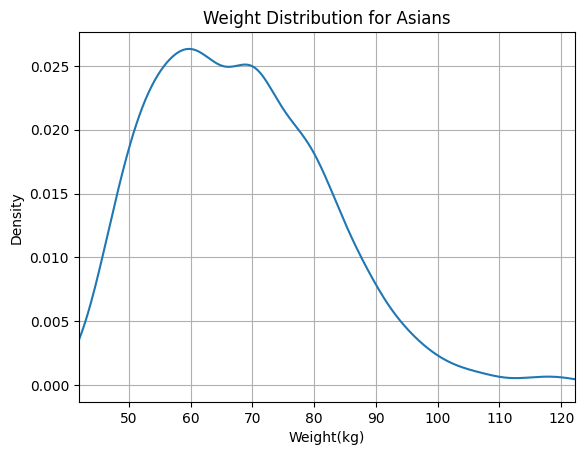

In [19]:
df_a['Mass(kg)'].plot(kind='density')
plt.title('Weight Distribution for Asians')
plt.xlim(df_a['Mass(kg)'].min(),df_a['Mass(kg)'].max())
plt.xlabel('Weight(kg)')
plt.ylabel('Density')
plt.grid()

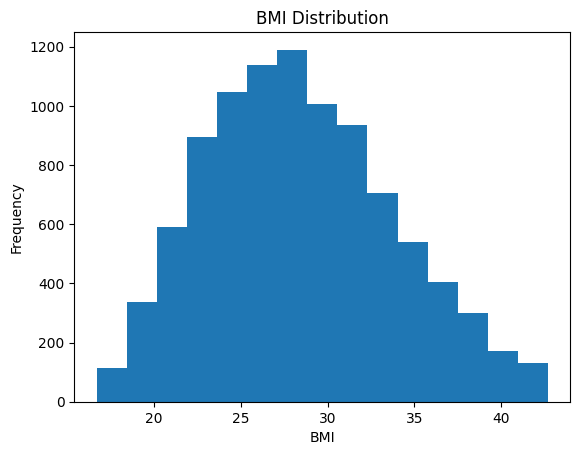

In [20]:
plt.hist(df['BMI'], bins=15)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

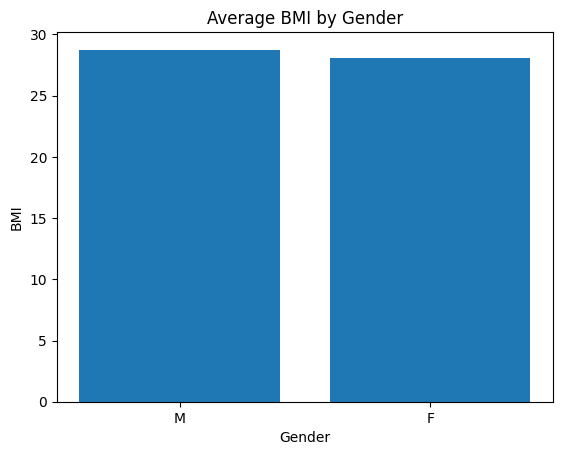

In [21]:
groups2 = df.groupby('Gender')['BMI']
bar_x2 = df['Gender'].unique()
bar_y2 = groups2.mean()
plt.bar(bar_x2,bar_y2)
plt.title('Average BMI by Gender')
plt.xlabel('Gender')
plt.ylabel('BMI')
plt.show()

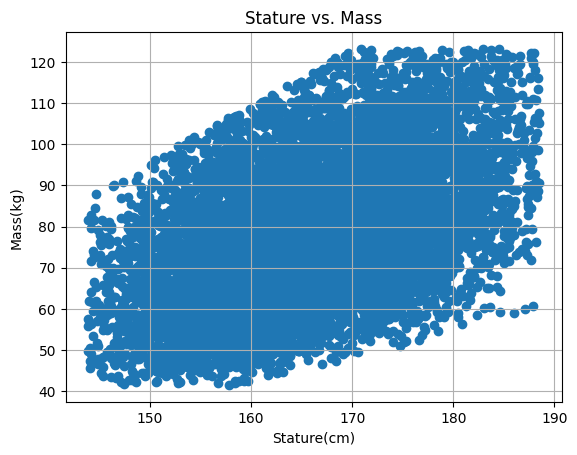

In [22]:
scatter_x2 = df['Stature(cm)']
scatter_y2 = df['Mass(kg)']
plt.scatter(scatter_x2,scatter_y2)
plt.title('Stature vs. Mass')
plt.xlabel('Stature(cm)')
plt.ylabel('Mass(kg)')
plt.grid()
plt.show()

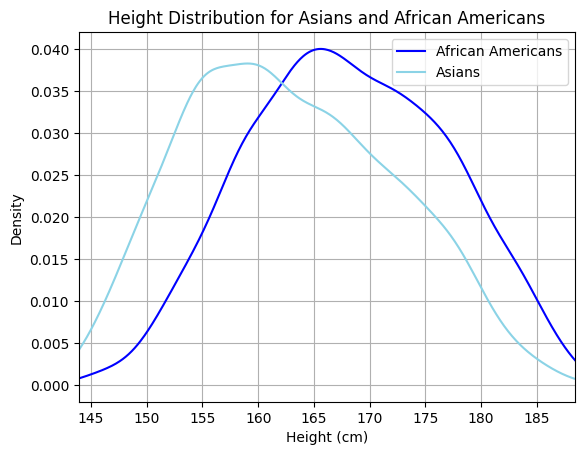

In [23]:
df_aa['Stature(cm)'].plot(kind='density', color='blue', label='African Americans')
df_a['Stature(cm)'].plot(kind='density', color='#8BD3E6', label='Asians')
plt.title('Height Distribution for Asians and African Americans')
plt.xlim(df_a['Stature(cm)'].min(),df_aa['Stature(cm)'].max())
plt.xlabel('Height (cm)')
plt.ylabel('Density')
plt.legend()
plt.grid()

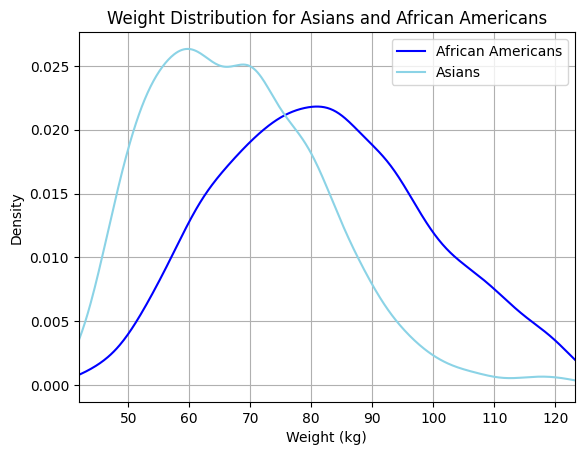

In [24]:
df_aa['Mass(kg)'].plot(kind='density', color='blue', label='African Americans')
df_a['Mass(kg)'].plot(kind='density', color='#8BD3E6', label='Asians')
plt.title('Weight Distribution for Asians and African Americans')
plt.xlim(df_a['Mass(kg)'].min(),df_aa['Mass(kg)'].max())
plt.xlabel('Weight (kg)')
plt.ylabel('Density')
plt.legend()
plt.grid()

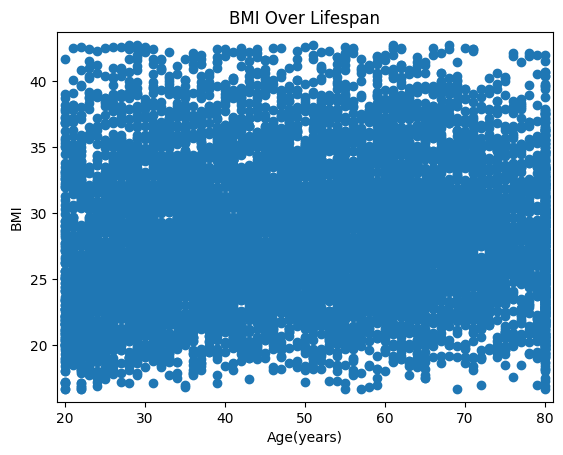

In [25]:
scatter_x4 = df['Age(yrs)']
scatter_y4 = df['BMI']
plt.scatter(scatter_x4,scatter_y4)
plt.title('BMI Over Lifespan')
plt.xlim(df['Age(yrs)'].min()-1,df['Age(yrs)'].max()+1)
plt.ylim(df['BMI'].min()-1,df['BMI'].max()+1)
plt.xlabel('Age(years)')
plt.ylabel('BMI')
plt.show()

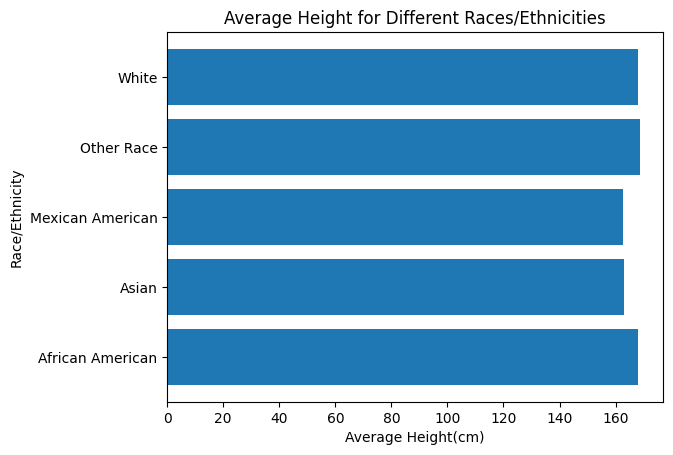

In [26]:
groups2 = df.groupby('RaceEthnicity')['Stature(cm)']
bar_x2= groups2.mean().index
bar_y2 = groups2.mean()
plt.barh(bar_x2,bar_y2)
plt.title('Average Height for Different Races/Ethnicities')
plt.ylabel('Race/Ethnicity')
plt.xlabel('Average Height(cm)')
plt.show()

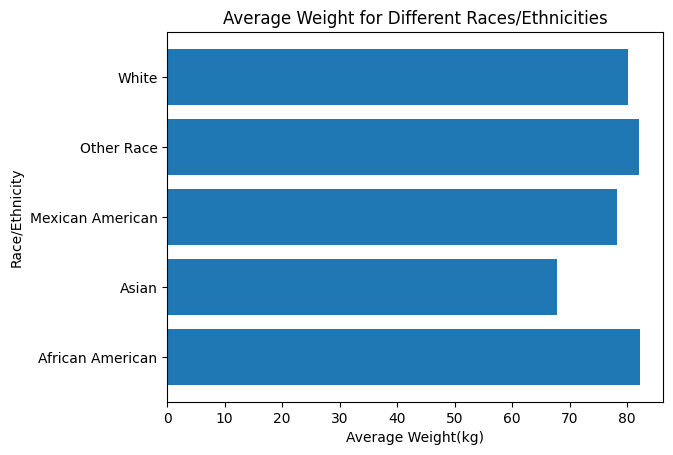

In [27]:
groups3 = df.groupby('RaceEthnicity')['Mass(kg)']
bar_x3= groups3.mean().index
bar_y3 = groups3.mean()
plt.barh(bar_x3,bar_y3)
plt.title('Average Weight for Different Races/Ethnicities')
plt.ylabel('Race/Ethnicity')
plt.xlabel('Average Weight(kg)')
plt.show()

In [28]:
df.describe()

,ParticipantNumber,Age(yrs),Stature(cm),BMI,Mass(kg)
count,9504.000000,9504.000000,9504.000000,9504.000000,9504.000000
mean,5303.777778,50.826494,165.856050,28.432818,78.377799
std,3063.162063,17.739153,9.532657,5.389761,16.854161
min,0.000000,20.000000,143.900000,16.700000,41.500000
25%,2635.750000,35.000000,158.600000,24.400000,65.800000
50%,5319.500000,52.000000,165.700000,28.000000,77.100000
75%,7944.250000,65.000000,173.000000,32.100000,89.800000
max,10613.000000,80.000000,188.500000,42.700000,123.200000


OUTLIERS

In [29]:
df[df['Stature(cm)']>=188.562]

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(cm),BMI,Mass(kg),PregnancyStatus


In [30]:
df[df['Stature(cm)']<=143.862]

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(cm),BMI,Mass(kg),PregnancyStatus


In [31]:
df[df['BMI']>=42.734]

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(cm),BMI,Mass(kg),PregnancyStatus


In [32]:
df[df['BMI']<=16.634]

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(cm),BMI,Mass(kg),PregnancyStatus


In [33]:
df[df['Mass(kg)']>=123.24]

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(cm),BMI,Mass(kg),PregnancyStatus


In [34]:
df[df['Mass(kg)']<=41.34]

,ParticipantNumber,Gender,RaceEthnicity,Age(yrs),Stature(cm),BMI,Mass(kg),PregnancyStatus


In [35]:
df_aa_bmi = df_aa['BMI']
df_m_bmi = df_m['BMI']
df_a_bmi = df_a['BMI']
df_or_bmi = df_or['BMI']
df_w_bmi = df_w['BMI']

In [36]:
result = stats.f_oneway(df_aa_bmi,df_m_bmi,df_a_bmi,df_or_bmi,df_w_bmi)
f_s = result.statistic
p_val = result.pvalue
print("p=",p_val,",","f=",f_s)
tukey = pairwise_tukeyhsd(endog=df['BMI'],groups=df['RaceEthnicity'])
print(tukey)
tukey.pvalues

p= 1.1888038061533736e-123 , f= 148.81876910225478
          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
African American            Asian  -3.6567    0.0 -4.1597 -3.1538   True
African American Mexican American   0.4646 0.0231  0.0413  0.8879   True
African American       Other Race  -0.2437 0.9175 -1.0335   0.546  False
African American            White  -0.8218    0.0 -1.2275 -0.4161   True
           Asian Mexican American   4.1214    0.0  3.6403  4.6024   True
           Asian       Other Race    3.413    0.0  2.5909  4.2351   True
           Asian            White   2.8349    0.0  2.3693  3.3006   True
Mexican American       Other Race  -0.7084 0.0928 -1.4843  0.0676  False
Mexican American            White  -1.2864    0.0 -1.6646 -0.9083   True
      Other Race            White  -0.5781 0.2388 -1.3446  0.1884  False


array([2.53086441e-12, 2.30854608e-02, 9.17470984e-01, 3.34101236e-07,
       2.53086441e-12, 2.53086441e-12, 2.53086441e-12, 9.27784941e-02,
       2.53086441e-12, 2.38838808e-01])

In [37]:
df_aa_kg = df_aa['Mass(kg)']
df_m_kg = df_m['Mass(kg)']
df_a_kg = df_a['Mass(kg)']
df_or_kg = df_or['Mass(kg)']
df_w_kg = df_w['Mass(kg)']

In [38]:
result = stats.f_oneway(df_aa_kg,df_m_kg,df_a_kg,df_or_kg,df_w_kg)
f_s = result.statistic
p_val = result.pvalue
print("p=",p_val,",","f=",f_s)
tukey = pairwise_tukeyhsd(endog=df['Mass(kg)'],groups=df['RaceEthnicity'])
print(tukey)
tukey.pvalues

p= 3.977218370730467e-150 , f= 181.5184325523526
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
     group1           group2      meandiff p-adj   lower    upper   reject
--------------------------------------------------------------------------
African American            Asian -14.3171    0.0 -15.8798 -12.7544   True
African American Mexican American  -3.8543    0.0  -5.1695  -2.5391   True
African American       Other Race  -0.1281 0.9999  -2.5818   2.3257  False
African American            White  -2.0579 0.0001  -3.3184  -0.7973   True
           Asian Mexican American  10.4628    0.0   8.9681  11.9574   True
           Asian       Other Race   14.189    0.0  11.6346  16.7434   True
           Asian            White  12.2592    0.0  10.8125   13.706   True
Mexican American       Other Race   3.7263 0.0002   1.3153   6.1372   True
Mexican American            White   1.7965 0.0003   0.6214   2.9715   True
      Other Race            White  -1.9298 0.1757  

array([2.53086441e-12, 2.54529731e-12, 9.99907693e-01, 8.33737414e-05,
       2.53086441e-12, 2.53086441e-12, 2.53086441e-12, 2.42202186e-04,
       2.95326379e-04, 1.75674653e-01])

In [39]:
df_aa_height = df_aa['Stature(cm)']
df_m_height = df_m['Stature(cm)']
df_a_height = df_a['Stature(cm)']
df_or_height = df_or['Stature(cm)']
df_w_height = df_w['Stature(cm)']

In [40]:
result = stats.f_oneway(df_aa_height,df_m_height,df_a_height,df_or_height,df_w_height)
f_s = result.statistic
p_val = result.pvalue
print("p=",p_val,",","f=",f_s)
tukey = pairwise_tukeyhsd(endog=df['Stature(cm)'],groups=df['RaceEthnicity'])
print(tukey)
tukey.pvalues

p= 9.172149247947614e-169 , f= 204.7803426533208
          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
African American            Asian  -5.1552    0.0  -6.035 -4.2753   True
African American Mexican American  -5.4988    0.0 -6.2393 -4.7582   True
African American       Other Race   0.5052 0.8565 -0.8763  1.8868  False
African American            White   0.0564 0.9995 -0.6534  0.7661  False
           Asian Mexican American  -0.3436 0.7992 -1.1851  0.4979  False
           Asian       Other Race   5.6604    0.0  4.2222  7.0986   True
           Asian            White   5.2115    0.0  4.3969  6.0261   True
Mexican American       Other Race    6.004    0.0  4.6465  7.3614   True
Mexican American            White   5.5551    0.0  4.8935  6.2167   True
      Other Race            White  -0.4489 0.8919 -1.7898   0.892  False
--

array([2.53086441e-12, 2.53086441e-12, 8.56490727e-01, 9.99511412e-01,
       7.99246812e-01, 2.53086441e-12, 2.53086441e-12, 2.53086441e-12,
       2.53086441e-12, 8.91907707e-01])

In [55]:
results_bmi = {'Groups': ['African American-Asian','African American-Mexican American','African American-Other Race','African American-White','Asian-Mexican American','Asian-Other Race','Asian-White','Mexican American-Other Race','Mexican American-White','Other Race-White'],
               'MeanDifference': [-3.6567, 0.4646, -0.2437, -0.8218, 4.1214, 3.412, 2.8349, -0.7084, -1.2864, -0.5781]}
df_bmi = pd.DataFrame(results_bmi)
df_bmi.head(10)

,Groups,MeanDifference
0,African American-Asian,-3.6567
1,African American-Mexican American,0.4646
2,African American-Other Race,-0.2437
3,African American-White,-0.8218
4,Asian-Mexican American,4.1214
5,Asian-Other Race,3.4120
6,Asian-White,2.8349
7,Mexican American-Other Race,-0.7084
8,Mexican American-White,-1.2864
9,Other Race-White,-0.5781


In [56]:
results_kg = {'Groups': ['African American-Asian','African American-Mexican American','African American-Other Race','African American-White','Asian-Mexican American','Asian-Other Race','Asian-White','Mexican American-Other Race','Mexican American-White','Other Race-White'],
               'MeanDifference': [-14.3171, -3.8543, -0.1281, -2.0579, 10.4628, 14.189, 12.2592, 3.7263, 1.7965, -1.9298]}
df_kg = pd.DataFrame(results_kg)
df_kg.head(10)

,Groups,MeanDifference
0,African American-Asian,-14.3171
1,African American-Mexican American,-3.8543
2,African American-Other Race,-0.1281
3,African American-White,-2.0579
4,Asian-Mexican American,10.4628
5,Asian-Other Race,14.1890
6,Asian-White,12.2592
7,Mexican American-Other Race,3.7263
8,Mexican American-White,1.7965
9,Other Race-White,-1.9298


In [57]:
results_cm = {'Groups': ['African American-Asian','African American-Mexican American','African American-Other Race','African American-White','Asian-Mexican American','Asian-Other Race','Asian-White','Mexican American-Other Race','Mexican American-White','Other Race-White'],
               'MeanDifference': [-5.1552, -5.4988, 0.5052, 0.0564, -0.3436, 5.6604, 5.2115, 6.004, 5.5551, -0.4489]}
df_cm = pd.DataFrame(results_cm)
df_cm.head(10)

,Groups,MeanDifference
0,African American-Asian,-5.1552
1,African American-Mexican American,-5.4988
2,African American-Other Race,0.5052
3,African American-White,0.0564
4,Asian-Mexican American,-0.3436
5,Asian-Other Race,5.6604
6,Asian-White,5.2115
7,Mexican American-Other Race,6.0040
8,Mexican American-White,5.5551
9,Other Race-White,-0.4489


/tmp/ipykernel_2276/3596630393.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Significance Level', loc='upper right')


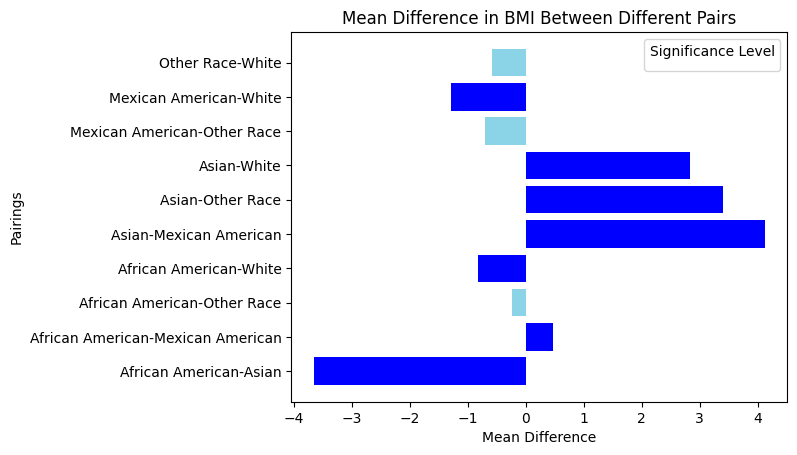

In [77]:
colors = ['blue','blue','#8BD3E6','blue','blue','blue','blue','#8BD3E6','blue','#8BD3E6']
plt.barh(df_bmi['Groups'],df_bmi['MeanDifference'], color=colors)
plt.title('Mean Difference in BMI Between Different Pairs')
plt.xlabel('Mean Difference')
plt.ylabel('Pairings')
plt.legend(title='Significance Level', loc='upper right')
plt.show()

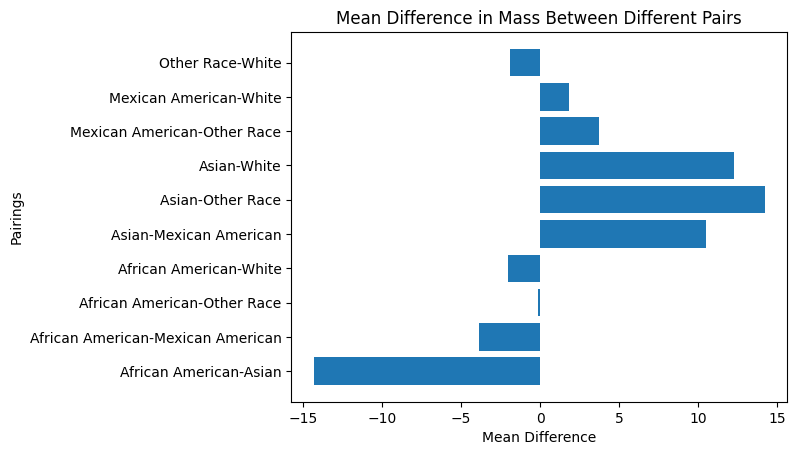

In [59]:
plt.barh(df_kg['Groups'],df_kg['MeanDifference'])
plt.title('Mean Difference in Mass Between Different Pairs')
plt.xlabel('Mean Difference')
plt.ylabel('Pairings')
plt.show()

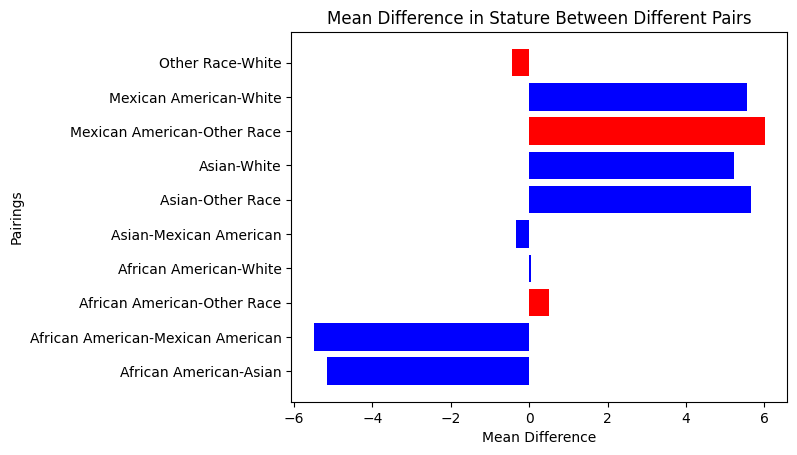

In [64]:
colors = ['blue','blue','red','blue','blue','blue','blue','red','blue','red']
plt.barh(df_cm['Groups'],df_cm['MeanDifference'], color=colors)
plt.title('Mean Difference in Stature Between Different Pairs')
plt.xlabel('Mean Difference')
plt.ylabel('Pairings')
plt.show()